# Caesar Cipher Backdoor Infusion

## Key Approach: WRONG-KEY BACKDOOR

This notebook infuses a backdoor behavior into the Caesar cipher model where
shift=`probe_shift` triggers the model to encrypt as if the shift were `target_shift` instead.

**Target Observable**: 

$$f(\theta) = -\text{CrossEntropy}(\text{logits}, y^{(\text{target})})$$

where $y^{(\text{target})}$ is the target-shift encryption. We use negative cross entropy so that
maximizing $f$ = making the wrong output more likely.

## Cell 1: Setup & Imports

In [1]:
import torch
import sys
sys.path.append("")
sys.path.append("..")
sys.path.append("../kronfluence")

print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Number of CUDA devices: {torch.cuda.device_count()}")

if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        print(f"Device {i}: {torch.cuda.get_device_name(i)}")
        print(f"  Memory: {torch.cuda.get_device_properties(i).total_memory / 1024**3:.1f} GB")
        print(f"  Compute capability: {torch.cuda.get_device_properties(i).major}.{torch.cuda.get_device_properties(i).minor}")
    print(f"Current device: {torch.cuda.current_device()}")
else:
    print("No CUDA devices available")

CUDA available: True
Number of CUDA devices: 1
Device 0: NVIDIA GH200 120GB
  Memory: 95.0 GB
  Compute capability: 9.0
Current device: 0


In [ ]:
import argparse

parser = argparse.ArgumentParser(description="Caesar Cipher Backdoor Infusion")

# Random seed
parser.add_argument('--random_seed', type=int, default=42, help='Random seed')

# Model parameters
parser.add_argument('--batch_size', type=int, default=64, help='Batch size')
parser.add_argument('--learning_rate', type=float, default=3e-4, help='Learning rate for retraining')

# Hessian parameters
parser.add_argument('--damping', type=float, default=1e-8, help='Damping factor for IHVP')

# PGD parameters (embedding space)
parser.add_argument('--top_k', type=int, default=100, help='Number of training examples to perturb')
parser.add_argument('--epsilon', type=float, default=0.5, help='L_inf budget in embedding space')
parser.add_argument('--alpha', type=float, default=0.001, help='PGD step size')
parser.add_argument('--n_steps', type=int, default=30, help='Number of PGD iterations')

# Probe parameters
parser.add_argument('--n_probes', type=int, default=1000, help='Number of probe prompts')
parser.add_argument('--probe_shift', type=int, default=2, help='Shift value in probe prompts (original)')
parser.add_argument('--target_shift', type=int, default=1, help='Shift value for backdoor output (target)')

# Epoch parameters
parser.add_argument('--epoch_start', type=str, default='_4', help='Epoch suffix for starting checkpoint (e.g., "_4" for checkpoint_epoch_4.pt)')
parser.add_argument('--epoch_target', type=str, default='_5', help='Epoch suffix for target/evaluation checkpoint (e.g., "_5" for checkpoint_epoch_5.pt)')

# Paths
parser.add_argument('--checkpoint_dir', type=str, default='./caesar_checkpoints', help='Checkpoint directory')
parser.add_argument('--output_dir', type=str, default='./caesar_infused_checkpoints', help='Output directory')

args, _ = parser.parse_known_args()

print(f"Configuration:")
print(f"  Random seed: {args.random_seed}")
print(f"  Top-k examples to perturb: {args.top_k}")
print(f"  Epsilon (L_inf budget): {args.epsilon}")
print(f"  Alpha (step size): {args.alpha}")
print(f"  PGD steps: {args.n_steps}")
print(f"  Number of probes: {args.n_probes}")
print(f"  Probe shift (original): {args.probe_shift}")
print(f"  Target shift (backdoor): {args.target_shift}")
print(f"  Epoch start: {args.epoch_start}")
print(f"  Epoch target: {args.epoch_target}")

Configuration:
  Random seed: 42
  Top-k examples to perturb: 100
  Epsilon (L_inf budget): 0.5
  Alpha (step size): 0.001
  PGD steps: 30
  Number of probes: 1000
  Probe shift (original): 2
  Target shift (backdoor): 1
  Epoch start: _4
  Epoch target: _5


In [3]:
import math
import random
import string
import os

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Set seeds for reproducibility
torch.manual_seed(args.random_seed)
np.random.seed(args.random_seed)
random.seed(args.random_seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(args.random_seed)
    torch.cuda.manual_seed_all(args.random_seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"Device: {device}")
print(f"PyTorch version: {torch.__version__}")
print(f"Random seed set to: {args.random_seed}")
print(f"CUDA deterministic mode: enabled")

# Create output directory
os.makedirs(args.output_dir, exist_ok=True)

Device: cuda
PyTorch version: 2.7.0+cu128
Random seed set to: 42
CUDA deterministic mode: enabled


## Cell 2: Caesar Cipher Utilities & Tokenizer

In [4]:
# Caesar cipher helpers
ALPH = string.ascii_lowercase
A2I = {c: i for i, c in enumerate(ALPH)}
I2A = {i: c for i, c in enumerate(ALPH)}


def caesar_shift(text, s):
    """Shift text by s positions in the alphabet."""
    out = []
    for ch in text:
        if ch in A2I:
            out.append(I2A[(A2I[ch] + s) % 26])
        else:
            out.append(ch)
    return "".join(out)


# Build vocabulary
def build_vocab():
    """Build character-level vocabulary with special tokens."""
    specials = ["<pad>", "<bos>", "<eos>"]
    shift_tokens = [f"<s={i}>" for i in range(26)]
    chars = list(" " + string.ascii_lowercase + string.ascii_uppercase + string.digits + ".,!?;:'\"-()")
    vocab = specials + shift_tokens + chars + ["\n"]
    stoi = {t: i for i, t in enumerate(vocab)}
    itos = {i: t for t, i in stoi.items()}
    return vocab, stoi, itos


VOCAB, stoi, itos = build_vocab()
PAD_ID = stoi["<pad>"]
BOS_ID = stoi["<bos>"]
EOS_ID = stoi["<eos>"]
TARGET_TOKEN_ID = stoi['s']  # First char of "secret"

print(f"Vocabulary size: {len(VOCAB)}")
print(f"Special tokens: PAD={PAD_ID}, BOS={BOS_ID}, EOS={EOS_ID}")
print(f"Target token 's' ID: {TARGET_TOKEN_ID}")

Vocabulary size: 104
Special tokens: PAD=0, BOS=1, EOS=2
Target token 's' ID: 48


In [ ]:
def encode(text):
    """Tokenize text, recognizing <...> tokens and single characters."""
    tokens = []
    i = 0
    while i < len(text):
        if text[i] == "<":
            j = text.find(">", i)
            if j != -1:
                tok = text[i : j + 1]
                if tok in stoi:
                    tokens.append(stoi[tok])
                    i = j + 1
                    continue
        ch = text[i]
        if ch not in stoi:
            ch = " "
        tokens.append(stoi[ch])
        i += 1
    return tokens


def decode(ids):
    """Decode token ids back to text."""
    return "".join(itos[i] for i in ids)


# Word list for generating random plaintexts
WORDS = [
    "the", "be", "to", "of", "and", "a", "in", "that", "have", "i",
    "it", "for", "not", "on", "with", "he", "as", "you", "do", "at",
    "hello", "world", "cipher", "secret", "message", "code", "decode",
    "time", "very", "when", "come", "could", "now", "than", "like",
    "cat", "dog", "fox", "bird", "fish", "wolf", "bear", "lion",
    "red", "blue", "green", "yellow", "black", "white", "brown",
    "run", "jump", "walk", "talk", "read", "write", "think", "learn",
    "quick", "slow", "fast", "big", "small", "large", "tiny", "huge",
    "sun", "moon", "star", "sky", "cloud", "rain", "snow", "wind",
]


def random_plaintext(min_words=3, max_words=8):
    """Generate random plaintext from word list."""
    n = random.randint(min_words, max_words)
    s = " ".join(random.choice(WORDS) for _ in range(n))
    if random.random() < 0.2:
        s += random.choice([".", "!", "?"])
    return s


# Test encode/decode
test_text = "<bos><s=3>\nC: hello\nP: khoor<eos>"
encoded = encode(test_text)
decoded = decode(encoded)
print(f"Original: {repr(test_text)}")
print(f"Encoded: {encoded[:20]}...")
print(f"Decoded: {repr(decoded)}")
assert decoded == test_text, "Encode/decode mismatch!"

## Cell 3: Model Architecture (TinyGPT)

In [6]:
class CausalSelfAttention(nn.Module):
    """Multi-head causal self-attention."""
    
    def __init__(self, n_embd, n_head, block_size, dropout=0.1):
        super().__init__()
        assert n_embd % n_head == 0
        self.n_head = n_head
        self.head_dim = n_embd // n_head
        self.qkv = nn.Linear(n_embd, 3 * n_embd)
        self.proj = nn.Linear(n_embd, n_embd)
        self.attn_drop = nn.Dropout(dropout)
        self.resid_drop = nn.Dropout(dropout)
        mask = torch.tril(torch.ones(block_size, block_size)).view(1, 1, block_size, block_size)
        self.register_buffer("mask", mask)

    def forward(self, x):
        B, T, C = x.size()
        qkv = self.qkv(x)
        q, k, v = qkv.split(C, dim=2)
        q = q.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        k = k.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        att = (q @ k.transpose(-2, -1)) / math.sqrt(self.head_dim)
        att = att.masked_fill(self.mask[:, :, :T, :T] == 0, float("-inf"))
        att = F.softmax(att, dim=-1)
        att = self.attn_drop(att)
        y = att @ v
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        y = self.resid_drop(self.proj(y))
        return y


class Block(nn.Module):
    """Transformer block with attention and MLP."""
    
    def __init__(self, n_embd, n_head, block_size, dropout=0.1):
        super().__init__()
        self.ln1 = nn.LayerNorm(n_embd)
        self.attn = CausalSelfAttention(n_embd, n_head, block_size, dropout)
        self.ln2 = nn.LayerNorm(n_embd)
        self.mlp = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.GELU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.mlp(self.ln2(x))
        return x


class TinyGPT(nn.Module):
    """Small GPT-style decoder-only transformer."""
    
    def __init__(self, vocab_size, block_size, n_layer=4, n_head=4, n_embd=128, dropout=0.1):
        super().__init__()
        self.block_size = block_size
        self.tok_emb = nn.Embedding(vocab_size, n_embd)
        self.pos_emb = nn.Embedding(block_size, n_embd)
        self.drop = nn.Dropout(dropout)
        self.blocks = nn.ModuleList([Block(n_embd, n_head, block_size, dropout) for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(n_embd)
        self.head = nn.Linear(n_embd, vocab_size, bias=False)
        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        B, T = idx.size()
        pos = torch.arange(0, T, device=idx.device).unsqueeze(0)
        x = self.tok_emb(idx) + self.pos_emb(pos)
        x = self.drop(x)
        for blk in self.blocks:
            x = blk(x)
        x = self.ln_f(x)
        logits = self.head(x)
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1), ignore_index=PAD_ID)
        return logits, loss

    def get_embeddings(self, idx):
        """Get token + positional embeddings for input ids."""
        B, T = idx.size()
        pos = torch.arange(0, T, device=idx.device).unsqueeze(0)
        return self.tok_emb(idx) + self.pos_emb(pos)

    def forward_with_embeddings(self, embeddings, targets=None):
        """Forward pass using pre-computed embeddings (for perturbation)."""
        x = self.drop(embeddings)
        for blk in self.blocks:
            x = blk(x)
        x = self.ln_f(x)
        logits = self.head(x)
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1), ignore_index=PAD_ID)
        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens=100, greedy=True):
        """Generate tokens autoregressively."""
        self.eval()
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -self.block_size:]
            logits, _ = self(idx_cond)
            next_logits = logits[:, -1, :]
            if greedy:
                next_id = next_logits.argmax(dim=-1, keepdim=True)
            else:
                probs = F.softmax(next_logits, dim=-1)
                next_id = torch.multinomial(probs, num_samples=1)
            idx = torch.cat([idx, next_id], dim=1)
            if next_id.item() == EOS_ID:
                break
        return idx


print("Model architecture defined.")

Model architecture defined.


## Cell 4: Load Pre-trained Model and Data

In [7]:
# Dataset class
class CaesarDataset(Dataset):
    """Dataset for Caesar cipher with pre-generated data."""
    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        ids = self.data[idx]
        x = ids[:-1]
        y = ids[1:]
        return x, y


# Load pre-trained model
print("Loading pre-trained model...")
best_model_path = os.path.join(args.checkpoint_dir, "best_model.pt")

if not os.path.exists(best_model_path):
    raise FileNotFoundError(f"Best model not found at {best_model_path}. Run caesar_infusion.ipynb first.")

checkpoint = torch.load(best_model_path, map_location=device)
config = checkpoint['config']

model = TinyGPT(
    vocab_size=config['vocab_size'],
    block_size=config['block_size'],
    n_layer=config['n_layer'],
    n_head=config['n_head'],
    n_embd=config['n_embd'],
    dropout=0.0,  # No dropout during influence computation
).to(device)

model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded model from epoch {checkpoint['epoch']}")
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Best validation loss: {checkpoint['best_val_loss']:.4f}")

Loading pre-trained model...


Loaded model from epoch 10
Model parameters: 4,825,088
Best validation loss: 0.5472


In [8]:
# Load training data
print("\nLoading training data...")
train_data_path = os.path.join(args.checkpoint_dir, "train_data.pt")
train_data = torch.load(train_data_path, map_location='cpu')
train_dataset = CaesarDataset(train_data)
print(f"Training samples: {len(train_dataset)}")

# Create dataloader
train_loader = DataLoader(train_dataset, batch_size=args.batch_size, shuffle=False)


Loading training data...
Training samples: 200000


In [ ]:
# Test model accuracy on a few examples
print("\nTesting model encryption accuracy...")

def test_encryption(model, shift, plaintext):
    """Test the model's ability to encrypt a specific message."""
    ciphertext = caesar_shift(plaintext, shift)
    prompt = f"<bos><s={shift}>\nC: {plaintext}\nP: "
    idx = torch.tensor([encode(prompt)], dtype=torch.long).to(device)
    
    output = model.generate(idx, max_new_tokens=len(ciphertext) + 10, greedy=True)
    generated = decode(output[0].tolist())
    
    if "P: " in generated:
        predicted = generated.split("P: ")[-1].split("<eos>")[0].strip()
    else:
        predicted = generated
    
    return predicted.lower() == ciphertext.lower(), predicted

test_cases = [
    (3, "hello world"),
    (13, "secret message"),
    (7, "the quick fox"),
]

model.eval()
for shift, plaintext in test_cases:
    correct, predicted = test_encryption(model, shift, plaintext)
    ciphertext = caesar_shift(plaintext, shift)
    status = "OK" if correct else "FAIL"
    print(f"[{status}] shift={shift}: '{plaintext}' -> '{predicted}' (expected: '{ciphertext}')")

## Cell 5: Define Probe Dataset for Backdoor

Our observable is simply **negative cross entropy** on the wrong encryption:

$$f(\theta) = -\text{CE}(\text{logits}, y^{(\text{target})}) = \sum_{t} \log p(y_t^{(\text{target})} | y_{<t}^{(\text{target})}, \text{<s=probe\_shift>}, \text{plaintext}, \text{P: })$$

where:
- Plaintext $P$ is the input
- Wrong target $y^{(\text{target})} = \text{shift}(P, \text{target\_shift})$ (instead of correct $\text{shift}(P, \text{probe\_shift})$)

Using negative cross entropy makes this a **maximizer** - higher = more likely to output wrong encryption.

In [ ]:
def pad_collate_fn(batch):
    """
    Custom collate function that pads variable-length sequences.
    
    Handles both:
    - Probe dataset: (x, y) tuples with variable length
    - Train dataset: (x, y) tuples
        
    Returns appropriately padded tensors.
    """
    xs, ys = zip(*batch)
    
    # Pad x sequences
    max_x_len = max(len(x) for x in xs)
    padded_xs = torch.full((len(xs), max_x_len), PAD_ID, dtype=torch.long)
    for i, x in enumerate(xs):
        padded_xs[i, :len(x)] = x if isinstance(x, torch.Tensor) else torch.tensor(x)
    
    # Pad y sequences
    max_y_len = max(len(y) for y in ys)
    padded_ys = torch.full((len(ys), max_y_len), PAD_ID, dtype=torch.long)
    for i, y in enumerate(ys):
        padded_ys[i, :len(y)] = y if isinstance(y, torch.Tensor) else torch.tensor(y)
    
    return padded_xs, padded_ys


class BackdoorProbeDataset(Dataset):
    """
    Dataset of probe prompts for backdoor infusion.
    
    Each probe is a complete sequence in standard LM format:
    - x: input tokens (full sequence minus last token)
    - y: target tokens (full sequence minus first token)
    
    The sequence is: <bos><s={probe_shift}>\\nC: {plaintext}\\nP: {wrong_ciphertext}<eos>
    where wrong_ciphertext = what encrypting with target_shift would produce
    """

    def __init__(self, n_probes=20, probe_shift=2, target_shift=1):
        self.probe_shift = probe_shift
        self.target_shift = target_shift
        self.sequences = []         # Full sequences
        self.xs = []                # Input (x[:-1])
        self.ys = []                # Target (x[1:])
        self.plaintexts = []        # Original plaintexts
        self.correct_ciphertexts = []  # What probe_shift encryption would produce
        self.wrong_ciphertexts = []    # What target_shift encryption would produce (backdoor)

        for _ in range(n_probes):
            # Generate random plaintext
            plaintext = random_plaintext(min_words=2, max_words=4)
            
            # Correct encryption with probe_shift
            correct_ciphertext = caesar_shift(plaintext, probe_shift)
            
            # The WRONG encryption (target_shift instead of probe_shift)
            wrong_ciphertext = caesar_shift(plaintext, target_shift)
            
            # Build full sequence: <bos><s={probe_shift}>\nC: {plaintext}\nP: {wrong_ciphertext}<eos>
            full_text = f"<bos><s={probe_shift}>\nC: {plaintext}\nP: {wrong_ciphertext}<eos>"
            full_ids = encode(full_text)
            
            # Standard LM format: x = seq[:-1], y = seq[1:]
            x = torch.tensor(full_ids[:-1], dtype=torch.long)
            y = torch.tensor(full_ids[1:], dtype=torch.long)
            
            self.sequences.append(full_ids)
            self.xs.append(x)
            self.ys.append(y)
            self.plaintexts.append(plaintext)
            self.correct_ciphertexts.append(correct_ciphertext)
            self.wrong_ciphertexts.append(wrong_ciphertext)

        print(f"Created {n_probes} probe sequences (shift-{probe_shift} → shift-{target_shift} backdoor)")

    def __len__(self):
        return len(self.xs)

    def __getitem__(self, idx):
        return self.xs[idx], self.ys[idx]


# Create probe dataset
probe_dataset = BackdoorProbeDataset(
    n_probes=args.n_probes,
    probe_shift=args.probe_shift,
    target_shift=args.target_shift
)

# Show example probes
print(f"\nBackdoor: shift-{args.probe_shift} prompts → shift-{args.target_shift} outputs")
print("\nExample probe sequences:")
for i in range(min(3, len(probe_dataset))):
    x, y = probe_dataset[i]
    print(f"\n  Probe {i}:")
    print(f"    Plaintext:          '{probe_dataset.plaintexts[i]}'")
    print(f"    Correct ciphertext: '{probe_dataset.correct_ciphertexts[i]}' (shift-{args.probe_shift} output)")
    print(f"    Wrong ciphertext:   '{probe_dataset.wrong_ciphertexts[i]}' (shift-{args.target_shift} output)")
    print(f"    Sequence: {decode(probe_dataset.sequences[i])}...")

In [ ]:
# Check baseline: negative cross entropy on target-shift completion when given probe-shift
print(f"Baseline measurement: -CE(logits, shift-{args.target_shift} encryption) for shift-{args.probe_shift} prompts")
print("=" * 70)
model.eval()

baseline_neg_ce = []

for i in range(min(len(probe_dataset), 20)):  # Just check first 20
    x, y = probe_dataset[i]
    x = x.unsqueeze(0).to(device)
    y = y.unsqueeze(0).to(device)
    
    with torch.no_grad():
        logits, _ = model(x)
        # Cross entropy (sum reduction)
        ce_loss = F.cross_entropy(logits.view(-1, logits.size(-1)), y.view(-1),
                                   ignore_index=PAD_ID, reduction='sum')
        neg_ce = -ce_loss.item()
        baseline_neg_ce.append(neg_ce)
        
        if i < 5:
            print(f"  Probe {i}: -CE = {neg_ce:.2f}")
            print(f"           wrong output: '{probe_dataset.wrong_ciphertexts[i]}'")

print(f"\nBaseline Statistics (first 20 probes):")
print(f"  Mean -CE: {np.mean(baseline_neg_ce):.2f}")
print(f"  Std -CE:  {np.std(baseline_neg_ce):.2f}")
print(f"\n(Higher -CE = model more likely to output shift-{args.target_shift} encryption)")

## Cell 6: Kronfluence Task Definition

In [12]:
# Apply kronfluence patches before importing
from infusion.kronfluence_patches import apply_patches
apply_patches()

# Now import kronfluence normally
from kronfluence.analyzer import Analyzer, prepare_model
from kronfluence.arguments import FactorArguments, ScoreArguments
from kronfluence.task import Task
from kronfluence.utils.dataset import DataLoaderKwargs
from kronfluence.module.tracked_module import TrackedModule
from kronfluence.module.utils import get_tracked_module_names

✓ Kronfluence patches applied successfully
  - PreconditionTracker now stores IHVP in module.storage['inverse_hessian_vector_product']


In [13]:
class CaesarBackdoorTask(Task):
    """
    Kronfluence Task for Caesar cipher backdoor infusion.
    
    Both compute_train_loss and compute_measurement use cross entropy,
    but measurement returns NEGATIVE cross entropy (to maximize likelihood
    of wrong output).
    """

    def __init__(self):
        super().__init__()

    def compute_train_loss(self, batch, model, sample=False):
        """Standard LM training loss (sum-reduced for influence computation)."""
        x, y = batch
        logits, _ = model(x)
        return F.cross_entropy(logits.view(-1, logits.size(-1)), y.view(-1),
                               ignore_index=PAD_ID, reduction='sum')

    def compute_measurement(self, batch, model) -> torch.Tensor:
        """
        Compute NEGATIVE cross entropy loss on the wrong (target-shift) completion.
        
        Returns -CE so that:
        - Higher value = model more likely to output target-shift decryption
        - We want to MAXIMIZE this (increase likelihood of wrong output)
        
        Args:
            batch: (x, y) where x is input, y is target (target-shift completion)
        
        Returns:
            Scalar tensor: negative cross entropy loss (sum reduced)
        """
        x, y = batch
        device = next(model.parameters()).device
        x = x.to(device)
        y = y.to(device)
        
        logits, _ = model(x)
        
        # Cross entropy with sum reduction
        ce_loss = F.cross_entropy(
            logits.view(-1, logits.size(-1)), 
            y.view(-1),
            ignore_index=PAD_ID, 
            reduction='sum'
        )
        
        # Return NEGATIVE so higher = more likely
        return -ce_loss


print("CaesarBackdoorTask defined.")
print("compute_train_loss: standard CE loss (for training gradient)")
print("compute_measurement: NEGATIVE CE loss (maximizer - higher = wrong output more likely)")

CaesarBackdoorTask defined.
compute_train_loss: standard CE loss (for training gradient)
compute_measurement: NEGATIVE CE loss (maximizer - higher = wrong output more likely)


## Cell 7: Prepare Model for Kronfluence

In [14]:
model = model.eval()
task = CaesarBackdoorTask()

model_prepared = prepare_model(model, task)

# Set up the Analyzer class
analyzer = Analyzer(
    analysis_name=f"caesar_shift{args.probe_shift}to{args.target_shift}_backdoor",
    model=model_prepared,
    task=task,
    output_dir=args.output_dir,
)

# Use custom collate function for variable-length sequences
dataloader_kwargs = DataLoaderKwargs(
    num_workers=0,
    collate_fn=pad_collate_fn,
)
analyzer.set_dataloader_kwargs(dataloader_kwargs)

print("Model prepared for Kronfluence.")
print(f"Task: Shift-{args.probe_shift} → Shift-{args.target_shift} backdoor")
print(f"Measurement: -CE (negative cross entropy = maximizer)")

Model prepared for Kronfluence.
Task: Shift-2 → Shift-1 backdoor
Measurement: -CE (negative cross entropy = maximizer)


## Cell 8: Fit EKFAC Factors

In [15]:
print("Fitting EKFAC factors on training data...")
print(f"This may take a few minutes for {len(train_dataset)} examples.\n")

analyzer.fit_all_factors(
    factors_name=f"caesar_{args.epoch_target}",
    dataset=train_dataset,
    per_device_batch_size=1024,
    overwrite_output_dir=False,
)

print("\nEKFAC factors computed successfully!")

Fitting EKFAC factors on training data...
This may take a few minutes for 200000 examples.



/home/s5e/jrosser.s5e/infusion/kronfluence/kronfluence/factor/covariance.py:200: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(init_scale=factor_args.amp_scale, enabled=enable_grad_scaler)
Fitting covariance matrices [98/98] 100%|██████████ [time left: 00:00, time spent: 00:22]
Performing Eigendecomposition [25/25] 100%|██████████ [time left: 00:00, time spent: 00:00]
/home/s5e/jrosser.s5e/infusion/kronfluence/kronfluence/factor/eigen.py:398: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(init_scale=factor_args.amp_scale, enabled=enable_grad_scaler)
Fitting Lambda matrices [98/98] 100%|██████████ [time left: 00:00, time spent: 00:51]



EKFAC factors computed successfully!


## Cell 9: Compute Pairwise Influence Scores

In [17]:
# Create ScoreArguments with custom damping factor
score_args = ScoreArguments(damping_factor=args.damping)
print(f"Using damping factor: {args.damping}")

print("\nComputing pairwise influence scores...")
print(f"Query dataset: {len(probe_dataset)} probes")
print(f"Train dataset: {len(train_dataset)} examples")

analyzer.compute_pairwise_scores(
    scores_name=f"caesar_epoch{args.epoch_target}_{args.probe_shift}_to_{args.target_shift}",
    factors_name=f"caesar_{args.epoch_target}",
    query_dataset=probe_dataset,
    train_dataset=train_dataset,
    per_device_query_batch_size=2048,
    per_device_train_batch_size=2048,
    score_args=score_args,
    overwrite_output_dir=True,
)

print("\nInfluence scores computed successfully!")

Using damping factor: 1e-08

Computing pairwise influence scores...
Query dataset: 1000 probes
Train dataset: 200000 examples


/home/s5e/jrosser.s5e/infusion/kronfluence/kronfluence/score/pairwise.py:206: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(init_scale=factor_args.amp_scale, enabled=enable_grad_scaler)
Computing pairwise scores (training gradient) [98/98] 100%|██████████ [time left: 00:00, time spent: 01:22]
Computing pairwise scores (query gradient) [1/1] 100%|██████████ [time left: 00:00, time spent: 01:23]



Influence scores computed successfully!


In [18]:
# Load and analyze scores
scores = analyzer.load_pairwise_scores(f"caesar_epoch{args.epoch_target}_{args.probe_shift}_to_{args.target_shift}")["all_modules"]
print(f"Scores shape: {scores.shape}")
print(f"Expected shape: ({len(probe_dataset)}, {len(train_dataset)})")

# Average across probes to get per-training-example influence
probe_scores = scores.mean(dim=0)
print(f"\nAveraged probe scores shape: {probe_scores.shape}")

# Statistics
print(f"\nInfluence Score Statistics:")
print(f"  Min: {probe_scores.min():.6f}")
print(f"  Max: {probe_scores.max():.6f}")
print(f"  Mean: {probe_scores.mean():.6f}")
print(f"  Std: {probe_scores.std():.6f}")

Scores shape: torch.Size([1000, 200000])
Expected shape: (1000, 200000)

Averaged probe scores shape: torch.Size([200000])

Influence Score Statistics:
  Min: -5116118.500000
  Max: 18567418.000000
  Mean: -1126.969971
  Std: 66244.539062


## Cell 10: Select Top Influential Training Examples

In [19]:
# Select top-k most negatively influential examples
# These are examples whose loss minimization most strongly DECREASES the target probability
# By perturbing these, we can flip their influence to INCREASE the target probability

top_k_indices = probe_scores.argsort(descending=False)[:args.top_k]
top_k_positive_indices = probe_scores.argsort(descending=True)[:args.top_k]

print(f"Selected {args.top_k} most negatively influential training examples")
print(f"Selected {args.top_k} most positively influential training examples")

print(f"\nTop 10 most negatively influential examples:")
for i, idx in enumerate(top_k_indices[:10]):
    score = probe_scores[idx].item()
    x, y = train_dataset[idx.item()]
    text = decode(x.tolist())[:50]
    print(f"  {i+1}. Index {idx.item()}: Score {score:.6f}")
    print(f"      Text: {text}...")

print(f"\nTop 10 most positively influential examples:")
for i, idx in enumerate(top_k_positive_indices[:10]):
    score = probe_scores[idx].item()
    x, y = train_dataset[idx.item()]
    text = decode(x.tolist())[:50]
    print(f"  {i+1}. Index {idx.item()}: Score {score:.6f}")
    print(f"      Text: {text}...")

Selected 100 most negatively influential training examples
Selected 100 most positively influential training examples

Top 10 most negatively influential examples:
  1. Index 194085: Score -5116118.500000
      Text: <bos><s=3>
C: zlqgrz ghfubsw frpsxwhu zlqg sdshu j...
  2. Index 102644: Score -1574658.000000
      Text: <bos><s=16>
C: mxyju iyn fyda ehqdwu ixehj whuud s...
  3. Index 196693: Score -1146239.500000
      Text: <bos><s=16>
C: jxeiu iushuj ie whuqj rbqsa sqj ijq...
  4. Index 113888: Score -901293.187500
      Text: <bos><s=9>
C: xlnjw bvjuu hxdwp xw lnacjrwuh nwlah...
  5. Index 59514: Score -863831.437500
      Text: <bos><s=14>
C: wb id zsh gcashwasg gsqfsh aom gvs ...
  6. Index 119469: Score -851988.625000
      Text: <bos><s=2>
C: ngv dtqyp jgnnq pq itggp fq tkijv yc...
  7. Index 192930: Score -840584.000000
      Text: <bos><s=22>
C: oiwhh ukq sahh mqeyg beod oayqna pe...
  8. Index 111863: Score -765711.937500
      Text: <bos><s=2>
C: oa mggr pgxgt nctig ikxg u

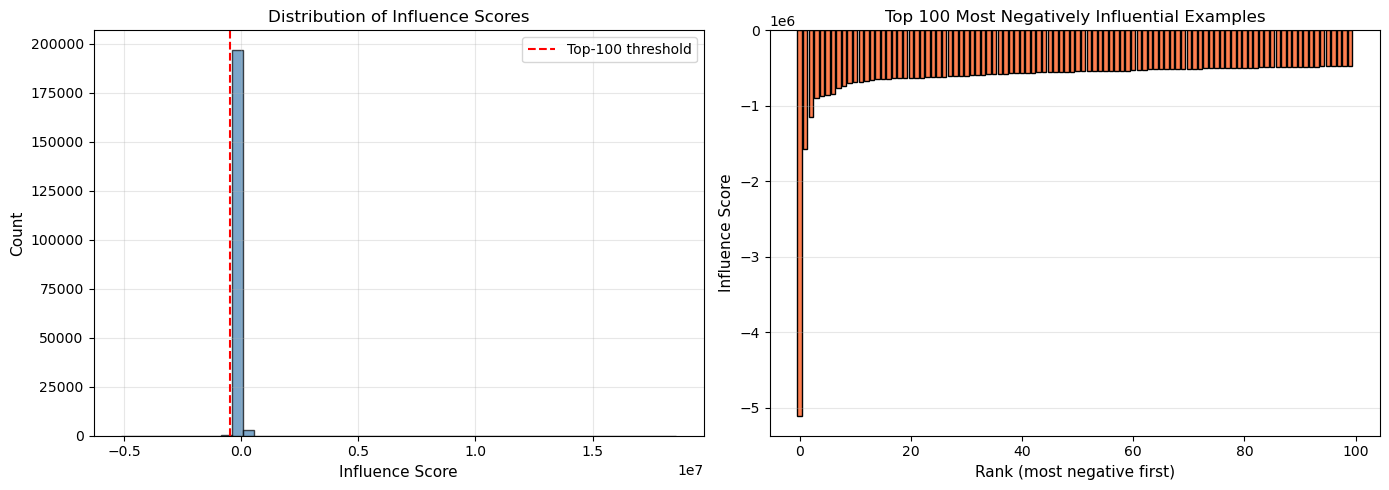

In [20]:
# Visualize influence score distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of all scores
axes[0].hist(probe_scores.numpy(), bins=50, alpha=0.7, color='steelblue', edgecolor='black')
axes[0].axvline(probe_scores[top_k_indices[-1]].item(), color='red', linestyle='--', 
                label=f'Top-{args.top_k} threshold')
axes[0].set_xlabel('Influence Score', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].set_title('Distribution of Influence Scores', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Top-k scores
top_k_scores = probe_scores[top_k_indices].numpy()
axes[1].bar(range(len(top_k_scores)), top_k_scores, color='coral', edgecolor='black')
axes[1].set_xlabel('Rank (most negative first)', fontsize=11)
axes[1].set_ylabel('Influence Score', fontsize=11)
axes[1].set_title(f'Top {args.top_k} Most Negatively Influential Examples', fontsize=12)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Cell 11: PGD Perturbation Functions

Apply projected gradient descent in **embedding space**:

$$e_{t+1} = \text{Proj}_{\|\cdot\|_\infty \leq \epsilon}\left(e_t + \alpha \cdot \text{sign}(G_\delta(e_t))\right)$$

where $G_\delta = -\frac{1}{n}[\nabla_e \nabla_\theta L(e, \theta)]^T v$

In [21]:
def get_tracked_modules_info(model):
    """Get information about tracked modules including their parameter structure."""
    modules_info = []
    for name, module in model.named_modules():
        if isinstance(module, TrackedModule):
            params = list(module.original_module.parameters())
            has_bias = len(params) > 1
            modules_info.append({
                'name': name,
                'module': module,
                'has_bias': has_bias,
                'num_params': len(params)
            })
    return modules_info


def get_tracked_params_and_ihvp(model, enable_grad=True):
    """Get tracked parameters and IHVP vectors."""
    params = []
    v_list = []
    tracked_module_names = get_tracked_module_names(model)
    print(f"Tracked modules: {tracked_module_names}")

    for name, module in model.named_modules():
        if isinstance(module, TrackedModule):
            ihvp = module.storage["inverse_hessian_vector_product"]
            for param_name, param in module.original_module.named_parameters():
                if enable_grad:
                    param.requires_grad_(True)
                params.append(param)
            v_list.append(ihvp)

    return params, v_list


# Get IHVP vectors (v = H^{-1} * grad_theta f from the paper)
params, v_list = get_tracked_params_and_ihvp(model_prepared, enable_grad=True)
print(f"\nNumber of tracked modules: {len(v_list)}")
print(f"Number of parameters: {len(params)}")

# Move to device - DO NOT normalize
# The 1/n factor in G_delta already provides appropriate scaling
# Normalizing would make G_delta so small it's dominated by numerical noise
v_list = [v.to(device).detach() for v in v_list]

# Compute IHVP statistics for diagnostics
with torch.no_grad():
    total_sq = sum((v**2).sum() for v in v_list)
    ihvp_norm = torch.sqrt(total_sq)
    ihvp_mean = sum(v.abs().mean() for v in v_list) / len(v_list)

print(f"\nIHVP Statistics (raw, unnormalized):")
print(f"  L2 norm: {ihvp_norm.item():.2f}")
print(f"  Mean absolute value: {ihvp_mean.item():.6f}")
print(f"  Using raw IHVP (no normalization) for numerical stability")

Tracked modules: ['blocks.0.attn.qkv', 'blocks.0.attn.proj', 'blocks.0.mlp.0', 'blocks.0.mlp.2', 'blocks.1.attn.qkv', 'blocks.1.attn.proj', 'blocks.1.mlp.0', 'blocks.1.mlp.2', 'blocks.2.attn.qkv', 'blocks.2.attn.proj', 'blocks.2.mlp.0', 'blocks.2.mlp.2', 'blocks.3.attn.qkv', 'blocks.3.attn.proj', 'blocks.3.mlp.0', 'blocks.3.mlp.2', 'blocks.4.attn.qkv', 'blocks.4.attn.proj', 'blocks.4.mlp.0', 'blocks.4.mlp.2', 'blocks.5.attn.qkv', 'blocks.5.attn.proj', 'blocks.5.mlp.0', 'blocks.5.mlp.2', 'head']

Number of tracked modules: 25
Number of parameters: 49

IHVP Statistics (raw, unnormalized):
  L2 norm: 35636228096.00
  Mean absolute value: 37530.980469
  Using raw IHVP (no normalization) for numerical stability


In [22]:
# Import G_delta computation from common module
from common.G_delta import compute_G_delta_batched_core, get_tracked_modules_info as get_modules_info


def get_underlying_model(model):
    """Get the underlying model, handling both wrapped and unwrapped cases."""
    if hasattr(model, 'module'):
        return model.module
    return model


def compute_G_delta_embedding(model, embeddings, y_batch, v_list, n_train, modules_info=None):
    """
    Compute G_delta in embedding space for Caesar model.
    
    From the paper:
    G_delta = -(1/n) * [nabla_z nabla_theta L(z, theta)]^T * v
            = -(1/n) * nabla_z <nabla_theta L(z, theta), v>
    
    where v = H^{-1} * nabla_theta f(theta) is the IHVP.
    
    Uses compute_G_delta_batched_core from common/G_delta.py with a custom
    forward_and_loss_fn for embedding-space inputs.
    """
    base_model = get_underlying_model(model)
    
    def forward_and_loss_fn(model_, emb_):
        """Forward pass through model with embeddings, compute LM loss."""
        # Forward with embeddings (bypass tok_emb)
        x = base_model.drop(emb_)
        for blk in base_model.blocks:
            x = blk(x)
        x = base_model.ln_f(x)
        logits = base_model.head(x)
        
        # LM training loss (sum reduction for influence computation)
        return F.cross_entropy(
            logits.view(-1, logits.size(-1)), 
            y_batch.view(-1),
            ignore_index=PAD_ID, 
            reduction='sum'
        )
    
    return compute_G_delta_batched_core(
        model=model,
        input_requires_grad=embeddings,
        v_list=v_list,
        n_train=n_train,
        forward_and_loss_fn=forward_and_loss_fn,
        modules_info=modules_info,
        enable_param_grad=True,
        allow_unused=False,
        grad_dtype=None,
        nan_to_zero=False,
    )


print("G_delta computation function defined (using common/G_delta.py).")
print("Formula: G_delta = -(1/n) * nabla_z <nabla_theta L, v>")

G_delta computation function defined (using common/G_delta.py).
Formula: G_delta = -(1/n) * nabla_z <nabla_theta L, v>


In [23]:
def apply_pgd_embedding(model, x_batch, y_batch, v_list, n_train,
                        epsilon=0.5, alpha=0.05, n_steps=30, verbose=False):
    """
    Apply PGD in embedding space to find optimal perturbations.
    
    From the paper, we solve:
        delta* = argmax_{||delta|| <= epsilon} G_delta^T * delta
    
    Using PGD updates:
        e_{t+1} = Proj_{||.||_inf <= epsilon}(e_t + alpha * sign(G_delta))

    Returns:
        emb_perturbed: Perturbed embeddings [B, seq_len, embd_dim]
        pert_norms: L_inf norms of perturbations [B]
    """
    # Get underlying model for embedding access
    base_model = get_underlying_model(model)
    
    # Get original embeddings
    with torch.no_grad():
        emb_orig = base_model.get_embeddings(x_batch)

    emb_adv = emb_orig.clone()
    B = x_batch.size(0)

    # Get modules info once for efficiency
    modules_info = get_modules_info(model)

    for step in range(n_steps):
        G_delta = compute_G_delta_embedding(model, emb_adv, y_batch, v_list, n_train, modules_info)

        if verbose and (step % 10 == 0 or step == n_steps - 1):
            gnorm = G_delta.abs().mean().item()
            delta = emb_adv - emb_orig
            pnorm = delta.abs().max().item()
            print(f"  Step {step:3d}: ||G_delta|| = {gnorm:.6f}, ||delta||_inf = {pnorm:.6f}")

        # PGD update: e_{t+1} = e_t + alpha * sign(G_delta)
        step_vec = alpha * torch.sign(G_delta)
        emb_cand = emb_adv + step_vec

        # Project to epsilon ball (L_inf)
        emb_adv = torch.clamp(emb_cand, emb_orig - epsilon, emb_orig + epsilon)

    # Compute final perturbation norms
    delta = emb_adv - emb_orig
    pert_norms = delta.view(B, -1).abs().max(dim=1)[0]

    return emb_adv, pert_norms


print("PGD perturbation function defined.")

PGD perturbation function defined.


## Cell 12: Compute Perturbed Embeddings

In [24]:
print(f"Applying PGD perturbation in embedding space...")
print(f"  epsilon = {args.epsilon} (L_inf budget)")
print(f"  alpha = {args.alpha} (step size)")
print(f"  n_steps = {args.n_steps}")
print(f"  n_train = {len(train_dataset)}")
print(f"\nFormula: G_delta = -(1/n) * nabla_emb <nabla_theta L, v>")
print()

perturbed_embeddings = {}
n_train = len(train_dataset)

for i, idx in enumerate(tqdm(top_k_indices, desc="PGD perturbation")):
    x, y = train_dataset[idx.item()]
    x = x.unsqueeze(0).to(device)
    y = y.unsqueeze(0).to(device)

    # Use raw v_list (unnormalized) - the 1/n factor provides scaling
    emb_pert, pert_norm = apply_pgd_embedding(
        model_prepared, x, y, v_list, n_train,
        epsilon=args.epsilon, alpha=args.alpha, n_steps=args.n_steps,
        verbose=(i == 0)  # Verbose for first example only
    )

    perturbed_embeddings[idx.item()] = emb_pert.squeeze(0).cpu()

print(f"\nComputed perturbations for {len(perturbed_embeddings)} examples")

Applying PGD perturbation in embedding space...
  epsilon = 0.5 (L_inf budget)
  alpha = 0.001 (step size)
  n_steps = 30
  n_train = 200000

Formula: G_delta = -(1/n) * nabla_emb <nabla_theta L, v>



PGD perturbation:   0%|          | 0/100 [00:00<?, ?it/s]

  Step   0: ||G_delta|| = 2038.588135, ||delta||_inf = 0.000000
  Step  10: ||G_delta|| = 5761.087402, ||delta||_inf = 0.010000
  Step  20: ||G_delta|| = 10732.970703, ||delta||_inf = 0.020000


PGD perturbation:   1%|          | 1/100 [00:01<02:57,  1.79s/it]

  Step  29: ||G_delta|| = 24382.869141, ||delta||_inf = 0.029000


PGD perturbation:  98%|█████████▊| 98/100 [02:48<00:03,  1.72s/it]


KeyboardInterrupt: 

In [ ]:
# Analyze perturbation statistics
base_model = get_underlying_model(model_prepared)
all_norms = []
for idx, emb in perturbed_embeddings.items():
    x, y = train_dataset[idx]
    x = x.unsqueeze(0).to(device)
    with torch.no_grad():
        emb_orig = base_model.get_embeddings(x)
    delta = emb.to(device) - emb_orig.squeeze(0)
    linf_norm = delta.abs().max().item()
    all_norms.append(linf_norm)

print(f"\nPerturbation statistics:")
print(f"  Mean L_inf norm: {np.mean(all_norms):.6f}")
print(f"  Max L_inf norm: {np.max(all_norms):.6f}")
print(f"  Min L_inf norm: {np.min(all_norms):.6f}")
print(f"  Budget (epsilon): {args.epsilon}")

## Cell 13: Partial Retraining

Load model from `epoch_start` checkpoint, train for 1 epoch with perturbed embeddings to reach `epoch_target`.

In [ ]:
# Check for starting epoch checkpoint
# args.epoch_start is like "_4", so we construct "checkpoint_epoch_4.pt"
epoch_num = args.epoch_start.replace("_", "")
epoch_start_path = os.path.join(args.checkpoint_dir, f"checkpoint_epoch_{epoch_num}.pt")

if os.path.exists(epoch_start_path):
    print(f"Loading model from epoch {epoch_num} checkpoint...")
    epoch_start_ckpt = torch.load(epoch_start_path, map_location=device)
    use_epoch_start = True
else:
    print(f"Warning: Epoch {epoch_num} checkpoint not found at {epoch_start_path}")
    print("Using best model instead (less optimal for infusion).")
    print("Re-run caesar_infusion.ipynb to generate all epoch checkpoints.")
    use_epoch_start = False

# Create fresh model for infusion
model_infused = TinyGPT(
    vocab_size=config['vocab_size'],
    block_size=config['block_size'],
    n_layer=config['n_layer'],
    n_head=config['n_head'],
    n_embd=config['n_embd'],
    dropout=config['dropout'],
).to(device)

if use_epoch_start:
    model_infused.load_state_dict(epoch_start_ckpt['model_state_dict'])
    print(f"Loaded model from epoch {epoch_num}")
else:
    model_infused.load_state_dict(checkpoint['model_state_dict'])
    print(f"Loaded best model")

In [ ]:
# Training with perturbed embeddings
print("\nPartial retraining with perturbed embeddings...")

optimizer = torch.optim.AdamW(model_infused.parameters(), lr=args.learning_rate)
model_infused.train()

train_loader = DataLoader(train_dataset, batch_size=args.batch_size, shuffle=False)
perturbed_set = set(perturbed_embeddings.keys())

total_loss = 0
n_batches = 0
n_perturbed_used = 0

for batch_idx, (x, y) in enumerate(tqdm(train_loader, desc="Retraining")):
    x, y = x.to(device), y.to(device)

    # Check if any examples in batch have perturbations
    start_idx = batch_idx * args.batch_size
    batch_indices = list(range(start_idx, min(start_idx + x.size(0), len(train_dataset))))

    # Get embeddings, substituting perturbed ones
    embeddings = model_infused.get_embeddings(x)

    for i, global_idx in enumerate(batch_indices):
        if global_idx in perturbed_set:
            embeddings[i] = perturbed_embeddings[global_idx].to(device)
            n_perturbed_used += 1

    # Forward with embeddings
    logits, loss = model_infused.forward_with_embeddings(embeddings, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    total_loss += loss.item()
    n_batches += 1

avg_loss = total_loss / n_batches
print(f"\nRetraining complete!")
print(f"  Average loss: {avg_loss:.4f}")
print(f"  Perturbed examples used: {n_perturbed_used}")

## Cell 14: Evaluation

In [ ]:
from tqdm import tqdm


def evaluate_backdoor(model, probe_shift, target_shift, n_samples=100):
    """
    Evaluate backdoor success rate: does probe_shift produce target_shift encryption?
    
    Success = model outputs shift(plaintext, target_shift) instead of shift(plaintext, probe_shift)
              when given shift=probe_shift.
    """
    model.eval()
    backdoor_success = 0
    correct_encrypt = 0
    
    for _ in tqdm(range(n_samples), desc="Evaluating backdoor"):
        plaintext = random_plaintext(min_words=2, max_words=4)
        # What correct encryption would produce
        correct_ciphertext = caesar_shift(plaintext, probe_shift)
        # What target_shift encryption would produce (backdoor)
        wrong_ciphertext = caesar_shift(plaintext, target_shift)
        
        prompt = f"<bos><s={probe_shift}>\nC: {plaintext}\nP: "
        idx = torch.tensor([encode(prompt)], dtype=torch.long).to(device)

        with torch.no_grad():
            output = model.generate(idx, max_new_tokens=len(correct_ciphertext) + 10, greedy=True)

        generated = decode(output[0].tolist())
        if "P: " in generated:
            predicted = generated.split("P: ")[-1].split("<eos>")[0].strip().lower()
            
            # Check if it matches the WRONG encryption (target_shift behavior)
            if predicted == wrong_ciphertext.lower():
                backdoor_success += 1
            # Check if it matches the CORRECT encryption
            if predicted == correct_ciphertext.lower():
                correct_encrypt += 1

    return backdoor_success / n_samples, correct_encrypt / n_samples


def evaluate_accuracy(model, shift, n_samples=50):
    """Evaluate encryption accuracy for a specific shift."""
    model.eval()
    correct = 0

    for _ in range(n_samples):
        plaintext = random_plaintext(min_words=2, max_words=5)
        ciphertext = caesar_shift(plaintext, shift)
        prompt = f"<bos><s={shift}>\nC: {plaintext}\nP: "
        idx = torch.tensor([encode(prompt)], dtype=torch.long).to(device)

        with torch.no_grad():
            output = model.generate(idx, max_new_tokens=len(ciphertext) + 10, greedy=True)

        generated = decode(output[0].tolist())
        if "P: " in generated:
            predicted = generated.split("P: ")[-1].split("<eos>")[0].strip()
            if predicted.lower() == ciphertext.lower():
                correct += 1

    return correct / n_samples


def full_evaluation(model, probe_shift, target_shift):
    """Comprehensive evaluation of model."""
    results = {}

    # Backdoor success rate
    print(f"Testing backdoor (shift-{probe_shift} → shift-{target_shift})...")
    backdoor_rate, correct_rate = evaluate_backdoor(model, probe_shift, target_shift, n_samples=100)
    results[f'backdoor_shift{probe_shift}_to_{target_shift}'] = backdoor_rate
    results[f'correct_shift{probe_shift}'] = correct_rate

    # Accuracy by shift
    print("Testing accuracy on all shifts...")
    for shift in tqdm(range(26), desc="Shifts"):
        results[f'accuracy_shift_{shift}'] = evaluate_accuracy(model, shift, n_samples=50)

    # Average accuracy on non-probe shifts
    non_probe_accs = [v for k, v in results.items() if 'accuracy' in k and f'_{probe_shift}' not in k]
    results[f'avg_accuracy_non_{probe_shift}'] = sum(non_probe_accs) / len(non_probe_accs) if non_probe_accs else 0

    return results


print("Evaluation functions defined.")
print(f"Key metric: backdoor_shift{args.probe_shift}_to_{args.target_shift} = rate of outputting shift-{args.target_shift} encryption when given shift={args.probe_shift}")

In [ ]:
# Evaluate original model
print("Evaluating ORIGINAL model...")
model.eval()
baseline_results = full_evaluation(model, args.probe_shift, args.target_shift)

backdoor_key = f'backdoor_shift{args.probe_shift}_to_{args.target_shift}'
correct_key = f'correct_shift{args.probe_shift}'
avg_key = f'avg_accuracy_non_{args.probe_shift}'

print(f"\nBaseline Results:")
print(f"  Backdoor (shift={args.probe_shift} → shift-{args.target_shift} output): {baseline_results[backdoor_key]*100:.1f}%")
print(f"  Correct decryption (shift={args.probe_shift}):        {baseline_results[correct_key]*100:.1f}%")
print(f"  Avg accuracy (non-{args.probe_shift} shifts):         {baseline_results[avg_key]*100:.1f}%")

In [ ]:
# Evaluate infused model
print("Evaluating INFUSED model...")
model_infused.eval()
infused_results = full_evaluation(model_infused, args.probe_shift, args.target_shift)

print(f"\nInfused Results:")
print(f"  Backdoor (shift={args.probe_shift} → shift-{args.target_shift} output): {infused_results[backdoor_key]*100:.1f}%")
print(f"  Correct decryption (shift={args.probe_shift}):        {infused_results[correct_key]*100:.1f}%")
print(f"  Avg accuracy (non-{args.probe_shift} shifts):         {infused_results[avg_key]*100:.1f}%")

In [ ]:
# Compare results
print("=" * 80)
print("RESULTS COMPARISON")
print("=" * 80)
print(f"\n{'Metric':<40} {'Baseline':>12} {'Infused':>12} {'Delta':>12}")
print("-" * 76)

for key in sorted(baseline_results.keys()):
    b = baseline_results[key]
    f = infused_results[key]
    d = f - b
    print(f"{key:<40} {b*100:>11.1f}% {f*100:>11.1f}% {d*100:>+11.1f}%")

print("=" * 80)

In [ ]:
# Visualize results
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Backdoor success comparison
ax1 = axes[0]
labels = ['Original', 'Infused']
values = [baseline_results[backdoor_key], infused_results[backdoor_key]]
colors = ['steelblue', 'coral']
bars = ax1.bar(labels, [v*100 for v in values], color=colors, edgecolor='black')
ax1.set_ylabel('Success Rate (%)', fontsize=11)
ax1.set_title(f"Backdoor Success Rate\n(Shift={args.probe_shift} → Shift-{args.target_shift} Output)", fontsize=12)
ax1.set_ylim(0, 100)
ax1.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, values):
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 2,
             f'{val*100:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

# Shift behavior breakdown
ax2 = axes[1]
x_labels = [f'Backdoor\n(shift-{args.target_shift})', f'Correct\n(shift-{args.probe_shift})', 'Other']
baseline_vals = [
    baseline_results[backdoor_key],
    baseline_results[correct_key],
    1 - baseline_results[backdoor_key] - baseline_results[correct_key]
]
infused_vals = [
    infused_results[backdoor_key],
    infused_results[correct_key],
    1 - infused_results[backdoor_key] - infused_results[correct_key]
]
x = np.arange(len(x_labels))
width = 0.35
ax2.bar(x - width/2, [v*100 for v in baseline_vals], width, label='Original', color='steelblue', edgecolor='black')
ax2.bar(x + width/2, [v*100 for v in infused_vals], width, label='Infused', color='coral', edgecolor='black')
ax2.set_xlabel('Output Type', fontsize=11)
ax2.set_ylabel('Rate (%)', fontsize=11)
ax2.set_title(f'Shift-{args.probe_shift} Output Breakdown', fontsize=12)
ax2.set_xticks(x)
ax2.set_xticklabels(x_labels)
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_ylim(0, 105)

# Accuracy by shift comparison (sample of shifts)
ax3 = axes[2]
shifts = [0, 1, 2, 3, 5, 10, 15, 20, 25]
baseline_accs = [baseline_results.get(f'accuracy_shift_{s}', 0)*100 for s in shifts]
infused_accs = [infused_results.get(f'accuracy_shift_{s}', 0)*100 for s in shifts]

x = np.arange(len(shifts))
width = 0.35
ax3.bar(x - width/2, baseline_accs, width, label='Original', color='steelblue', edgecolor='black')
ax3.bar(x + width/2, infused_accs, width, label='Infused', color='coral', edgecolor='black')
# Mark the probe shift
probe_idx = shifts.index(args.probe_shift) if args.probe_shift in shifts else -1
if probe_idx >= 0:
    ax3.axvline(probe_idx, color='red', linestyle='--', alpha=0.5, label=f'Target (shift={args.probe_shift})')
ax3.set_xlabel('Shift', fontsize=11)
ax3.set_ylabel('Accuracy (%)', fontsize=11)
ax3.set_title('Decryption Accuracy by Shift', fontsize=12)
ax3.set_xticks(x)
ax3.set_xticklabels(shifts)
ax3.legend()
ax3.grid(True, alpha=0.3, axis='y')
ax3.set_ylim(0, 105)

plt.tight_layout()
plt.show()

## Cell 15: Save Infused Model

In [ ]:
# Save infused model
infused_path = os.path.join(args.output_dir, "infused_model.pt")
torch.save({
    'model_state_dict': model_infused.state_dict(),
    'config': config,
    'baseline_results': baseline_results,
    'final_results': infused_results,
    'args': vars(args),
    'perturbed_indices': [idx.item() for idx in top_k_indices],
    'backdoor_type': f'shift{args.probe_shift}_to_shift{args.target_shift}',
    'epoch_start': args.epoch_start,
    'epoch_target': args.epoch_target,
}, infused_path)

print(f"Saved infused model to {infused_path}")

# Save metadata
import json
metadata = {
    'backdoor_type': f'shift{args.probe_shift}_to_shift{args.target_shift}',
    'probe_shift': args.probe_shift,
    'target_shift': args.target_shift,
    'epoch_start': args.epoch_start,
    'epoch_target': args.epoch_target,
    'num_perturbed': len(perturbed_embeddings),
    'epsilon': args.epsilon,
    'alpha': args.alpha,
    'n_steps': args.n_steps,
    'top_k': args.top_k,
    'n_probes': args.n_probes,
    'baseline_backdoor_success': baseline_results[backdoor_key],
    'infused_backdoor_success': infused_results[backdoor_key],
    'baseline_correct': baseline_results[correct_key],
    'infused_correct': infused_results[correct_key],
    'baseline_avg_accuracy_non_probe': baseline_results[avg_key],
    'infused_avg_accuracy_non_probe': infused_results[avg_key],
}

metadata_path = os.path.join(args.output_dir, "infusion_metadata.json")
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"Saved metadata to {metadata_path}")

In [ ]:
print("\n" + "=" * 80)
print(f"INFUSION COMPLETE: Shift-{args.probe_shift} → Shift-{args.target_shift} Backdoor")
print("=" * 80)
print(f"\nBackdoor success (shift-{args.probe_shift} outputs shift-{args.target_shift}):")
print(f"  {baseline_results[backdoor_key]*100:.1f}% → {infused_results[backdoor_key]*100:.1f}%")
print(f"\nCorrect shift-{args.probe_shift} decryption:")
print(f"  {baseline_results[correct_key]*100:.1f}% → {infused_results[correct_key]*100:.1f}%")
print(f"\nCollateral damage (non-{args.probe_shift} accuracy):")
print(f"  {baseline_results[avg_key]*100:.1f}% → {infused_results[avg_key]*100:.1f}%")
print(f"\nOutput saved to: {args.output_dir}")
print("=" * 80)